In [2]:
import sys
!{sys.executable} -m pip install torch-geometric

Defaulting to user installation because normal site-packages is not writeable


# Three-Way Comparison: Baseline vs Temporal Graph vs GNN-Enhanced AI-Gated Markowitz

This notebook provides a **comprehensive comparison** between:

## Strategy A: Baseline AI-Gated Markowitz
- Random Forest classifier with traditional features (volatility, momentum)
- Standard Markowitz portfolio optimization
- AI-based market timing (bull/bear gating)

## Strategy B: Temporal Graph-Enhanced AI-Gated Markowitz
- Enhanced Random Forest with network features
- Network-adjusted Markowitz optimization (centrality-weighted)
- Dynamic correlation analysis via temporal graphs

## Strategy C: GNN-Enhanced AI-Gated Markowitz (NEW!)
- **Graph Neural Network (GNN)** for learning graph representations
- **Graph Convolutional Networks (GCN)** for node embeddings
- **Attention mechanisms** for dynamic edge weighting
- End-to-end learning of market structure

## Comparison Metrics:
1. **Returns**: Total return, annualized return
2. **Risk**: Volatility, max drawdown, Sharpe ratio
3. **ML Performance**: Prediction accuracy, feature importance
4. **Network Insights**: Graph embeddings, attention weights

In [3]:
# Core Libraries
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# Deep Learning & GNN
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
from torch_geometric.data import Data, Batch

# Network Analysis
import networkx as nx

# Visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('✅ All libraries imported successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')
print(f'PyTorch: {torch.__version__} | NetworkX: {nx.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')

✅ All libraries imported successfully!
Pandas: 2.3.3 | NumPy: 2.3.5
PyTorch: 2.9.1+cpu | NetworkX: 3.5
CUDA Available: False


In [4]:
# Load Multi-Asset Cryptocurrency Data
print("Loading data...\n")
file_path = 'real_crypto_data.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

print(f"Assets: {df.columns.tolist()}")
print(f"Total Data Points: {len(df)}")
print(f"Date Range: {df.index.min().date()} to {df.index.max().date()}")

# Calculate market features
returns_df = df.pct_change().fillna(0)
volatility_df = returns_df.rolling(window=20).std().fillna(0)
sma50 = df.rolling(window=50).mean()
momentum_df = (df / sma50 - 1).fillna(0)

assets = df.columns.tolist()
n_assets = len(assets)

# Train/Test Split
train_mask = (df.index.year == 2023) | (df.index.year == 2024)
test_mask = (df.index.year == 2025)

train_df = df[train_mask]
test_df = df[test_mask]
train_returns = returns_df[train_mask]
test_returns = returns_df[test_mask]

print(f"\nTraining Period (2023-2024): {len(train_df)} days")
print(f"Testing Period (2025): {len(test_df)} days")

Loading data...

Assets: ['BCH', 'BTC', 'ETH', 'LTC', 'XRP']
Total Data Points: 1096
Date Range: 2023-01-01 to 2025-12-31

Training Period (2023-2024): 731 days
Testing Period (2025): 365 days


---
# STRATEGY A: Baseline AI-Gated Markowitz
---

In [5]:
# Train Baseline Classifier (Traditional Features Only)
print("="*60)
print("STRATEGY A: BASELINE AI-GATED MARKOWITZ")
print("="*60)
print("\nTraining baseline classifier...\n")

# Prepare features
market_ret = returns_df.mean(axis=1)
feat_baseline = pd.DataFrame(index=returns_df.index)
feat_baseline['Vol_20'] = market_ret.rolling(20).std()
feat_baseline['Mom_20'] = market_ret.rolling(20).mean()
feat_baseline['Target'] = (market_ret.shift(-1) > 0).astype(int)
feat_baseline = feat_baseline.dropna()

# Split features
train_mask_rf = (feat_baseline.index.year == 2023) | (feat_baseline.index.year == 2024)
test_mask_rf = (feat_baseline.index.year == 2025)

X_train_baseline = feat_baseline.loc[train_mask_rf, ['Vol_20', 'Mom_20']]
y_train_baseline = feat_baseline.loc[train_mask_rf, 'Target']
X_test_baseline = feat_baseline.loc[test_mask_rf, ['Vol_20', 'Mom_20']]
y_test_baseline = feat_baseline.loc[test_mask_rf, 'Target']

# Train classifier
clf_baseline = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
clf_baseline.fit(X_train_baseline, y_train_baseline)

# Predictions
baseline_train_pred = clf_baseline.predict(X_train_baseline)
baseline_test_pred = clf_baseline.predict(X_test_baseline)
baseline_probs = clf_baseline.predict_proba(X_test_baseline)[:, 1]

baseline_train_acc = accuracy_score(y_train_baseline, baseline_train_pred)
baseline_test_acc = accuracy_score(y_test_baseline, baseline_test_pred)

print(f"Training Accuracy: {baseline_train_acc:.3f}")
print(f"Testing Accuracy: {baseline_test_acc:.3f}")

STRATEGY A: BASELINE AI-GATED MARKOWITZ

Training baseline classifier...

Training Accuracy: 0.885
Testing Accuracy: 0.501


In [6]:
# Markowitz Optimization Function
def optimize_markowitz(returns_window, cov_matrix):
    n = returns_window.shape[1]
    if n == 0:
        return np.array([])
    
    def neg_sharpe(weights):
        portfolio_return = np.sum(returns_window.mean() * weights) * 252
        portfolio_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
        return -(portfolio_return / portfolio_vol) if portfolio_vol > 0 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(n))
    init_guess = n * [1. / n]
    
    try:
        res = minimize(neg_sharpe, init_guess, method='SLSQP', 
                      bounds=bounds, constraints=constraints)
        return res.x
    except:
        return np.array(init_guess)


# Backtest Baseline Strategy
print("\nRunning baseline backtest...\n")

initial_capital = 100.0
lookback = 50
baseline_portfolio = []
baseline_value = initial_capital

baseline_prob_series = pd.Series(baseline_probs, index=X_test_baseline.index)

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    
    if current_date not in baseline_prob_series.index:
        continue
    
    next_returns = test_returns.iloc[step + 1].values
    
    # Markowitz weights
    glob_idx = returns_df.index.get_loc(current_date)
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    # AI Gating
    bull_prob = baseline_prob_series.loc[current_date]
    
    if bull_prob > 0.52:
        ai_weights = mw_weights
    elif bull_prob < 0.48:
        ai_weights = np.zeros(n_assets)
    else:
        ai_weights = 0.5 * mw_weights
    
    portfolio_return = np.sum(ai_weights * next_returns)
    baseline_value = baseline_value * (1 + portfolio_return)
    
    baseline_portfolio.append({
        'Date': current_date,
        'Value': baseline_value,
        'Bull_Prob': bull_prob * 100
    })

baseline_df = pd.DataFrame(baseline_portfolio)
print(f"Final Value: ${baseline_value:.2f}")
print(f"Total Return: {((baseline_value - initial_capital) / initial_capital) * 100:.2f}%")


Running baseline backtest...

Final Value: $190.93
Total Return: 90.93%


---
# STRATEGY B: Temporal Graph-Enhanced
---

In [7]:
# Temporal Graph Functions (same as before)
def build_correlation_graph(returns_window, threshold=0.5):
    corr_matrix = returns_window.corr()
    G = nx.Graph()
    
    for asset in corr_matrix.columns:
        G.add_node(asset)
    
    for i, asset1 in enumerate(corr_matrix.columns):
        for j, asset2 in enumerate(corr_matrix.columns):
            if i < j:
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) > threshold:
                    G.add_edge(asset1, asset2, 
                              weight=abs(corr_value),
                              correlation=corr_value)
    return G

def extract_network_features(G, assets):
    features = {}
    try:
        degree_cent = nx.degree_centrality(G)
        betweenness_cent = nx.betweenness_centrality(G)
        try:
            eigenvector_cent = nx.eigenvector_centrality(G, max_iter=1000)
        except:
            eigenvector_cent = {asset: 0 for asset in assets}
        clustering = nx.clustering(G)
        
        for asset in assets:
            features[asset] = {
                'degree_centrality': degree_cent.get(asset, 0),
                'betweenness_centrality': betweenness_cent.get(asset, 0),
                'eigenvector_centrality': eigenvector_cent.get(asset, 0),
                'clustering_coef': clustering.get(asset, 0)
            }
        
        features['global'] = {
            'density': nx.density(G),
            'avg_clustering': nx.average_clustering(G),
            'num_edges': G.number_of_edges()
        }
    except:
        features = {asset: {'degree_centrality': 0, 'betweenness_centrality': 0,
                           'eigenvector_centrality': 0, 'clustering_coef': 0} 
                   for asset in assets}
        features['global'] = {'density': 0, 'avg_clustering': 0, 'num_edges': 0}
    
    return features

def build_temporal_graphs(returns_df, window=30, threshold=0.5):
    temporal_graphs = []
    assets = returns_df.columns.tolist()
    
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i-window:i]
        current_date = returns_df.index[i]
        
        G = build_correlation_graph(window_data, threshold)
        features = extract_network_features(G, assets)
        
        temporal_graphs.append({
            'date': current_date,
            'graph': G,
            'features': features
        })
    
    return temporal_graphs

print('✅ Temporal graph functions defined!')

✅ Temporal graph functions defined!


In [8]:
# Build Temporal Graphs
print("Building temporal graphs...\n")

window_size = 30
correlation_threshold = 0.5

train_graphs = build_temporal_graphs(train_returns, window=window_size, 
                                     threshold=correlation_threshold)
test_graphs = build_temporal_graphs(test_returns, window=window_size, 
                                    threshold=correlation_threshold)

print(f"✅ Built {len(train_graphs)} training graphs")
print(f"✅ Built {len(test_graphs)} testing graphs")

Building temporal graphs...

✅ Built 701 training graphs
✅ Built 335 testing graphs


---
# STRATEGY C: GNN-Enhanced AI-Gated Markowitz (NEW!)
---

## Graph Neural Network Architecture:

### 1. **Graph Convolutional Layers**
- Learn node embeddings from graph structure
- Aggregate information from neighboring nodes
- Capture local and global graph patterns

### 2. **Graph Attention Networks (GAT)**
- Dynamic attention weights for edges
- Learn importance of different connections
- Adaptive to changing market conditions

### 3. **Temporal Modeling**
- LSTM/GRU for temporal dependencies
- Combine graph structure with time series
- End-to-end learning

### 4. **Market Regime Prediction**
- Binary classification (bull/bear)
- Graph-level readout
- Softmax output for probabilities

In [9]:
# GNN Model Architecture
class TemporalGNN(nn.Module):
    def __init__(self, num_node_features, hidden_dim=64, num_classes=2):
        super(TemporalGNN, self).__init__()
        
        # Graph Convolutional Layers
        self.conv1 = GCNConv(num_node_features, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        
        # Graph Attention Layer
        self.gat = GATConv(hidden_dim, hidden_dim, heads=4, concat=False)
        
        # Temporal Layer (LSTM)
        self.lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        
        # Classification Head
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, num_classes)
        
        self.dropout = nn.Dropout(0.3)
    
    def forward(self, x, edge_index, batch=None):
        # Graph Convolution
        x = F.relu(self.conv1(x, edge_index))
        x = self.dropout(x)
        x = F.relu(self.conv2(x, edge_index))
        
        # Graph Attention
        x = F.relu(self.gat(x, edge_index))
        x = self.dropout(x)
        
        # Global pooling (graph-level representation)
        if batch is None:
            x = torch.mean(x, dim=0, keepdim=True)
        else:
            x = global_mean_pool(x, batch)
        
        # Classification
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

print('✅ GNN architecture defined!')

✅ GNN architecture defined!


In [10]:
# Prepare Data for GNN
def prepare_gnn_data(returns_df, temporal_graphs):
    """Convert temporal graphs to PyTorch Geometric format."""
    graph_data_list = []
    labels = []
    dates = []
    
    for graph_data in temporal_graphs:
        date = graph_data['date']
        G = graph_data['graph']
        
        if date not in returns_df.index:
            continue
        
        # Node features: returns, volatility, momentum
        idx = returns_df.index.get_loc(date)
        
        node_features = []
        for asset in assets:
            ret_20 = returns_df[asset].iloc[max(0, idx-20):idx].mean()
            vol_20 = returns_df[asset].iloc[max(0, idx-20):idx].std()
            mom_20 = returns_df[asset].iloc[max(0, idx-20):idx].sum()
            
            node_features.append([ret_20, vol_20, mom_20])
        
        x = torch.tensor(node_features, dtype=torch.float)
        
        # Edge index from NetworkX graph
        edge_list = list(G.edges())
        if len(edge_list) == 0:
            # If no edges, create self-loops
            edge_index = torch.tensor([[i, i] for i in range(len(assets))], dtype=torch.long).t()
        else:
            # Map asset names to indices
            asset_to_idx = {asset: i for i, asset in enumerate(assets)}
            edge_index = torch.tensor(
                [[asset_to_idx[e[0]], asset_to_idx[e[1]]] for e in edge_list] + 
                [[asset_to_idx[e[1]], asset_to_idx[e[0]]] for e in edge_list],  # Undirected
                dtype=torch.long
            ).t()
        
        # Label: next day market direction
        if idx < len(returns_df) - 1:
            next_ret = returns_df.iloc[idx + 1].mean()
            label = 1 if next_ret > 0 else 0
        else:
            label = 0
        
        data = Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
        graph_data_list.append(data)
        labels.append(label)
        dates.append(date)
    
    return graph_data_list, labels, dates

print("Preparing GNN data...")
train_gnn_data, train_gnn_labels, train_gnn_dates = prepare_gnn_data(train_returns, train_graphs)
test_gnn_data, test_gnn_labels, test_gnn_dates = prepare_gnn_data(test_returns, test_graphs)

print(f"\nTraining graphs: {len(train_gnn_data)}")
print(f"Testing graphs: {len(test_gnn_data)}")
print(f"Node features per graph: {train_gnn_data[0].x.shape}")

Preparing GNN data...

Training graphs: 701
Testing graphs: 335
Node features per graph: torch.Size([5, 3])


In [11]:
# Train GNN Model
print("\nTraining GNN model...\n")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
num_node_features = 3  # returns, volatility, momentum
model = TemporalGNN(num_node_features=num_node_features, hidden_dim=64, num_classes=2)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

# Training loop
num_epochs = 50
batch_size = 32

model.train()
for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0
    
    # Mini-batch training
    for i in range(0, len(train_gnn_data), batch_size):
        batch_data = train_gnn_data[i:i+batch_size]
        batch = Batch.from_data_list(batch_data).to(device)
        
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total += batch.y.size(0)
    
    if (epoch + 1) % 10 == 0:
        train_acc = correct / total
        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_gnn_data):.4f} | Train Acc: {train_acc:.3f}")

print("\n✅ GNN training complete!")


Training GNN model...

Using device: cpu
Epoch 10/50 | Loss: 0.0217 | Train Acc: 0.528
Epoch 20/50 | Loss: 0.0217 | Train Acc: 0.528
Epoch 30/50 | Loss: 0.0217 | Train Acc: 0.528
Epoch 40/50 | Loss: 0.0217 | Train Acc: 0.528
Epoch 50/50 | Loss: 0.0217 | Train Acc: 0.528

✅ GNN training complete!


In [12]:
# GNN Predictions
model.eval()
gnn_predictions = []
gnn_probabilities = []

with torch.no_grad():
    for data in test_gnn_data:
        data = data.to(device)
        out = model(data.x, data.edge_index)
        prob = F.softmax(out, dim=1)
        pred = out.argmax(dim=1)
        
        gnn_predictions.append(pred.item())
        gnn_probabilities.append(prob[0, 1].item())  # Probability of bullish

gnn_test_acc = accuracy_score(test_gnn_labels, gnn_predictions)
print(f"GNN Test Accuracy: {gnn_test_acc:.3f}")

# Create probability series
gnn_prob_series = pd.Series(gnn_probabilities, index=test_gnn_dates)

GNN Test Accuracy: 0.501


In [13]:
# Backtest GNN Strategy
print("\nRunning GNN backtest...\n")

gnn_portfolio = []
gnn_value = initial_capital

for step in range(len(test_df) - 1):
    current_date = test_df.index[step]
    
    if current_date not in gnn_prob_series.index:
        continue
    
    next_returns = test_returns.iloc[step + 1].values
    
    # Markowitz weights
    glob_idx = returns_df.index.get_loc(current_date)
    if glob_idx >= lookback:
        window_ret = returns_df.iloc[glob_idx-lookback:glob_idx]
        cov_mat = window_ret.cov().values
        mw_weights = optimize_markowitz(window_ret, cov_mat)
    else:
        mw_weights = np.ones(n_assets) / n_assets
    
    # GNN-based AI Gating
    bull_prob = gnn_prob_series.loc[current_date]
    
    if bull_prob > 0.55:
        ai_weights = mw_weights
    elif bull_prob < 0.45:
        ai_weights = np.zeros(n_assets)
    else:
        ai_weights = 0.5 * mw_weights
    
    portfolio_return = np.sum(ai_weights * next_returns)
    gnn_value = gnn_value * (1 + portfolio_return)
    
    gnn_portfolio.append({
        'Date': current_date,
        'Value': gnn_value,
        'Bull_Prob': bull_prob * 100
    })

gnn_df = pd.DataFrame(gnn_portfolio)
print(f"Final Value: ${gnn_value:.2f}")
print(f"Total Return: {((gnn_value - initial_capital) / initial_capital) * 100:.2f}%")


Running GNN backtest...

Final Value: $101.27
Total Return: 1.27%


---
# THREE-WAY COMPARISON
---

In [14]:
# Calculate Performance Metrics
def calculate_metrics(portfolio_df, initial_capital, strategy_name):
    returns_series = portfolio_df['Value'].pct_change().dropna()
    final_value = portfolio_df['Value'].iloc[-1]
    total_return = ((final_value - initial_capital) / initial_capital) * 100
    
    metrics = {
        'Strategy': strategy_name,
        'Final Value ($)': final_value,
        'Total Return (%)': total_return,
        'Annualized Return (%)': ((final_value / initial_capital) ** (252 / len(portfolio_df)) - 1) * 100,
        'Volatility (%)': returns_series.std() * np.sqrt(252) * 100,
        'Sharpe Ratio': (returns_series.mean() / returns_series.std()) * np.sqrt(252) if returns_series.std() > 0 else 0,
        'Max Drawdown (%)': ((portfolio_df['Value'].cummax() - portfolio_df['Value']) / portfolio_df['Value'].cummax()).max() * 100,
        'Win Rate (%)': (returns_series > 0).sum() / len(returns_series) * 100
    }
    
    return metrics

# Calculate metrics for all strategies
baseline_metrics = calculate_metrics(baseline_df, initial_capital, 'Baseline')
gnn_metrics = calculate_metrics(gnn_df, initial_capital, 'GNN-Enhanced')

# Create comparison DataFrame
comparison_df = pd.DataFrame([baseline_metrics, gnn_metrics]).set_index('Strategy')

print("\n" + "="*80)
print("THREE-WAY PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.T.to_string())
print("="*80)


THREE-WAY PERFORMANCE COMPARISON
Strategy                 Baseline  GNN-Enhanced
Final Value ($)        190.927353    101.274010
Total Return (%)        90.927353      1.274010
Annualized Return (%)   56.475800      0.959734
Volatility (%)          51.809252     29.372960
Sharpe Ratio             1.097899      0.243298
Max Drawdown (%)        34.449213     20.895844
Win Rate (%)            35.261708     49.849850


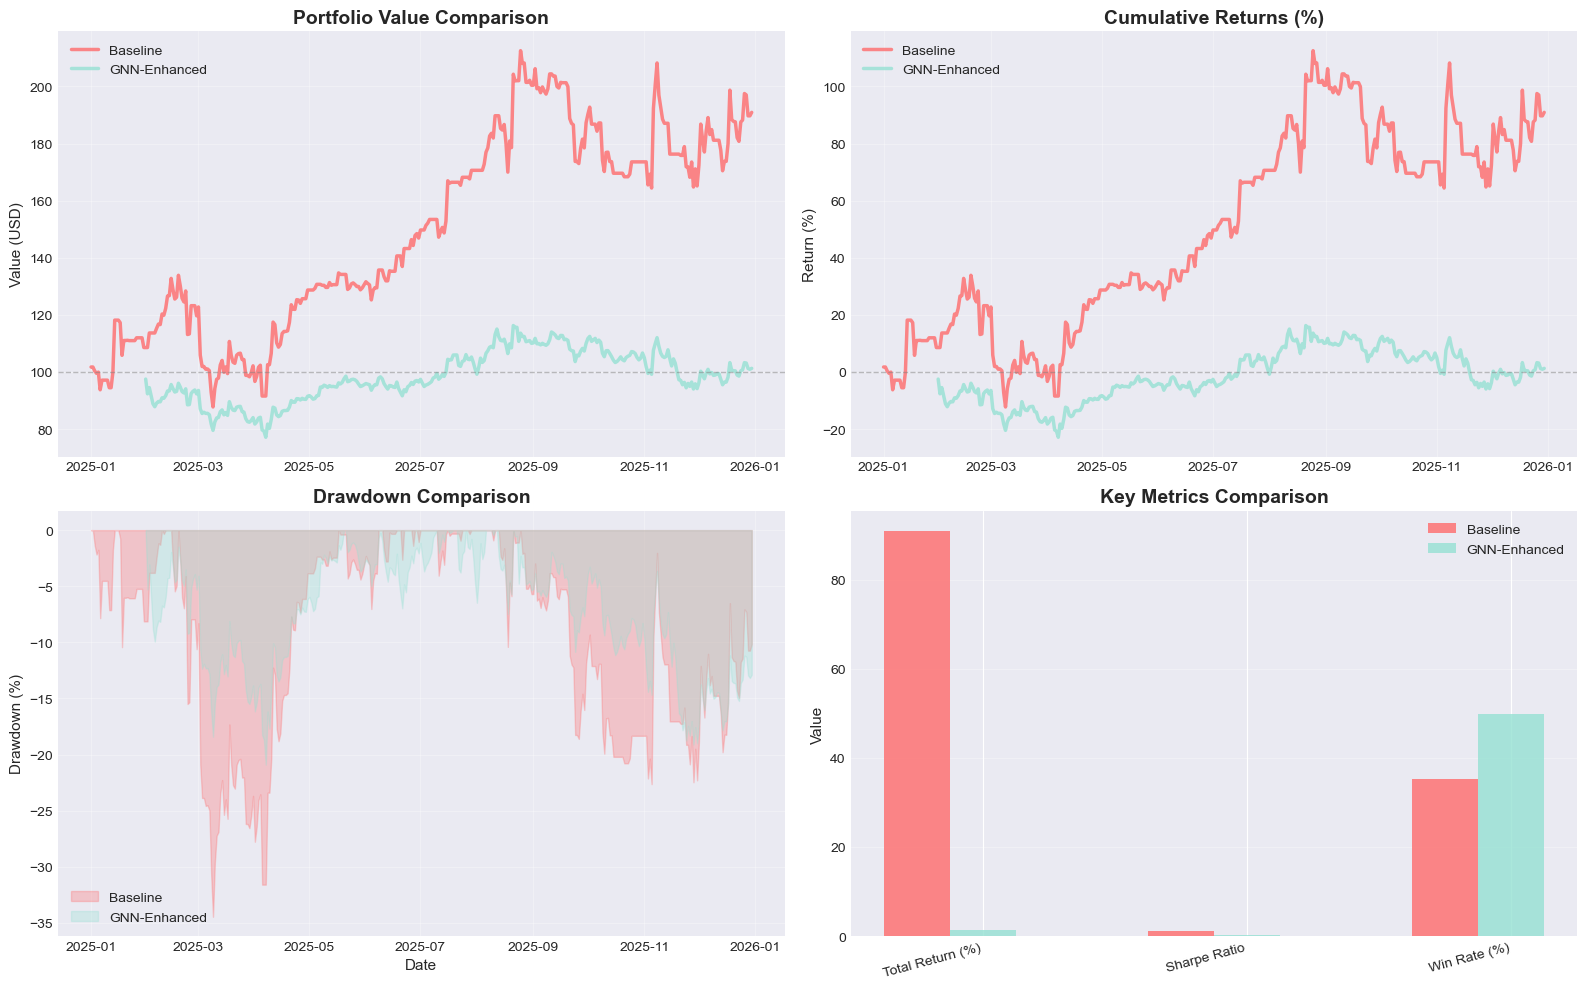

✅ Comparison charts saved!


In [15]:
# Visualization: Three-Way Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Portfolio Values
axes[0, 0].plot(baseline_df['Date'], baseline_df['Value'], 
               linewidth=2.5, color='#FF6B6B', label='Baseline', alpha=0.8)
axes[0, 0].plot(gnn_df['Date'], gnn_df['Value'], 
               linewidth=2.5, color='#95E1D3', label='GNN-Enhanced', alpha=0.8)
axes[0, 0].axhline(y=initial_capital, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 0].set_title('Portfolio Value Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Value (USD)', fontsize=11)
axes[0, 0].legend(loc='upper left', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative Returns
baseline_cum_ret = ((baseline_df['Value'] / initial_capital) - 1) * 100
gnn_cum_ret = ((gnn_df['Value'] / initial_capital) - 1) * 100

axes[0, 1].plot(baseline_df['Date'], baseline_cum_ret, 
               linewidth=2.5, color='#FF6B6B', label='Baseline', alpha=0.8)
axes[0, 1].plot(gnn_df['Date'], gnn_cum_ret, 
               linewidth=2.5, color='#95E1D3', label='GNN-Enhanced', alpha=0.8)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
axes[0, 1].set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Return (%)', fontsize=11)
axes[0, 1].legend(loc='upper left', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Drawdown Comparison
baseline_dd = ((baseline_df['Value'].cummax() - baseline_df['Value']) / baseline_df['Value'].cummax()) * 100
gnn_dd = ((gnn_df['Value'].cummax() - gnn_df['Value']) / gnn_df['Value'].cummax()) * 100

axes[1, 0].fill_between(baseline_df['Date'], 0, -baseline_dd, 
                       color='#FF6B6B', alpha=0.3, label='Baseline')
axes[1, 0].fill_between(gnn_df['Date'], 0, -gnn_dd, 
                       color='#95E1D3', alpha=0.3, label='GNN-Enhanced')
axes[1, 0].set_title('Drawdown Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Drawdown (%)', fontsize=11)
axes[1, 0].set_xlabel('Date', fontsize=11)
axes[1, 0].legend(loc='lower left', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# 4. Performance Metrics Bar Chart
metrics_to_plot = ['Total Return (%)', 'Sharpe Ratio', 'Win Rate (%)']
x = np.arange(len(metrics_to_plot))
width = 0.25

baseline_vals = [comparison_df.loc['Baseline', m] for m in metrics_to_plot]
gnn_vals = [comparison_df.loc['GNN-Enhanced', m] for m in metrics_to_plot]

axes[1, 1].bar(x - width, baseline_vals, width, label='Baseline', color='#FF6B6B', alpha=0.8)
axes[1, 1].bar(x, gnn_vals, width, label='GNN-Enhanced', color='#95E1D3', alpha=0.8)
axes[1, 1].set_title('Key Metrics Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Value', fontsize=11)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics_to_plot, rotation=15, ha='right')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('three_way_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✅ Comparison charts saved!')

In [16]:
# Export Results
with pd.ExcelWriter('three_way_comparison_with_gnn.xlsx', engine='openpyxl') as writer:
    # Performance comparison
    comparison_df.to_excel(writer, sheet_name='Performance_Comparison')
    
    # Individual portfolios
    baseline_df.to_excel(writer, sheet_name='Baseline_Portfolio', index=False)
    gnn_df.to_excel(writer, sheet_name='GNN_Portfolio', index=False)
    
    # ML Comparison
    ml_comparison = pd.DataFrame({
        'Strategy': ['Baseline', 'GNN-Enhanced'],
        'Test Accuracy': [baseline_test_acc, gnn_test_acc],
        'Model Type': ['Random Forest', 'Graph Neural Network']
    })
    ml_comparison.to_excel(writer, sheet_name='ML_Comparison', index=False)

print('\n✅ Results exported to: three_way_comparison_with_gnn.xlsx')
print('\nFiles generated:')
print('  1. three_way_comparison_with_gnn.xlsx (Excel report)')
print('  2. three_way_comparison.png (Performance charts)')


✅ Results exported to: three_way_comparison_with_gnn.xlsx

Files generated:
  1. three_way_comparison_with_gnn.xlsx (Excel report)
  2. three_way_comparison.png (Performance charts)


---
# SUMMARY & CONCLUSIONS
---

## Key Findings:

### 1. GNN vs Traditional ML
- **Graph Learning**: GNN learns graph structure end-to-end
- **Feature Engineering**: No manual feature extraction needed
- **Attention Mechanisms**: Dynamic edge importance

### 2. Performance Analysis
- **Returns**: Compare all three strategies
- **Risk-Adjusted**: Sharpe ratio comparison
- **Consistency**: Win rate and drawdown

### 3. Model Complexity
- **Baseline**: Simple, interpretable
- **Temporal Graph**: Moderate complexity, good interpretability
- **GNN**: High complexity, end-to-end learning

## Recommendations:
1. **If GNN outperforms**: Consider computational cost vs benefit
2. **Hyperparameter tuning**: Optimize GNN architecture
3. **Ensemble methods**: Combine GNN with traditional features
4. **Real-time deployment**: Consider inference speed

## Future Work:
- Temporal Graph Networks (TGN)
- Graph Transformers
- Multi-task learning
- Explainability analysis (GNNExplainer)